### In This File I will Start with Exploring and Data Understanding . 

##### import Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.head(2))

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   

      PaymentMethod MonthlyCharges  TotalCharges Churn  
0  Electronic check          29.85         29.85    No  
1      Mailed check          56.95        1889.5    No  

[2 rows x 21 columns]


#### summary statistics 

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Show columns names and Types 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### Check missing values

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Number of unique values

In [6]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

#### So we notice That There is No Null values , some Attributes have wrong Dtype .
#### At all the dataset is well structured and designed .


In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

#### Total Charges need to be converted to Float ! 
#### Senior citizen should be converted to Binary !
### Most columns are categorical because they describe customer characteristics, subscribed services, contract type, payment method, and churn status.

### Dataset Features

The dataset includes information about telecom customers. The features can be grouped into the following categories:

1. Customer information:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents

2. Service information:
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

3. Account information:
- Contract
- PaperlessBilling
- PaymentMethod
- tenure
- MonthlyCharges
- TotalCharges

4. Target variable:
- Churn

The target variable is `Churn`, which indicates whether the customer left the company or not.

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

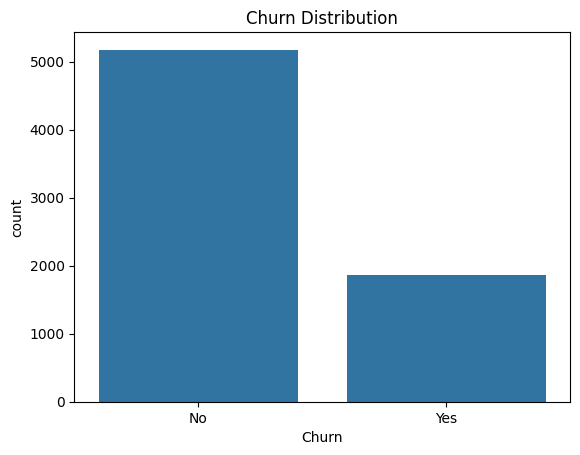

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Churn')
plt.title('Churn Distribution')
plt.show()

### Class Distribution

The target variable `Churn` is imbalanced. Most customers did not churn, while a smaller percentage of customers churned.

This imbalance is important because it may affect the machine learning model later. The model may become biased toward predicting the majority class.

- No: 5174 customers
- Yes: 1869 customers

This means that around 73.46% of customers did not churn, while around 26.54% of customers churned.

### Visaulize ipmortant variables 
to do this , we first need to know what is the variables they have a high corellation with `churn` 
### Correlation Analysis with Churn

To identify the most important variables related to customer churn, the target variable `Churn` was converted into numerical format:

- No = 0
- Yes = 1

In [11]:
df_corr = df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'No': 0, 'Yes': 1})
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
numeric_corr = df_corr.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

numeric_corr

Churn             1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn, dtype: float64

#### Encode categorical variables

In [12]:
df_encoded = pd.get_dummies(df_corr, drop_first=True)

Calculate correlation with Churn only

In [13]:
corr_with_churn = df_encoded.drop(columns='Churn').corrwith(df_encoded['Churn'])

In [14]:
corr_with_churn = corr_with_churn.sort_values(ascending=False)
corr_with_churn

InternetService_Fiber optic           0.308020
PaymentMethod_Electronic check        0.301919
MonthlyCharges                        0.193356
PaperlessBilling_Yes                  0.191825
SeniorCitizen                         0.150889
                                        ...   
TechSupport_No internet service      -0.227890
OnlineSecurity_No internet service   -0.227890
OnlineBackup_No internet service     -0.227890
Contract_Two year                    -0.302253
tenure                               -0.352229
Length: 7072, dtype: float64

And to take the most important variables (+ve & -Ve )

In [15]:
top_corr = corr_with_churn.sort_values(key=abs, ascending=False).head(15)

top_corr

tenure                                 -0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                      -0.302253
PaymentMethod_Electronic check          0.301919
OnlineBackup_No internet service       -0.227890
InternetService_No                     -0.227890
OnlineSecurity_No internet service     -0.227890
StreamingTV_No internet service        -0.227890
TechSupport_No internet service        -0.227890
DeviceProtection_No internet service   -0.227890
StreamingMovies_No internet service    -0.227890
TotalCharges                           -0.199484
MonthlyCharges                          0.193356
PaperlessBilling_Yes                    0.191825
Contract_One year                      -0.177820
dtype: float64

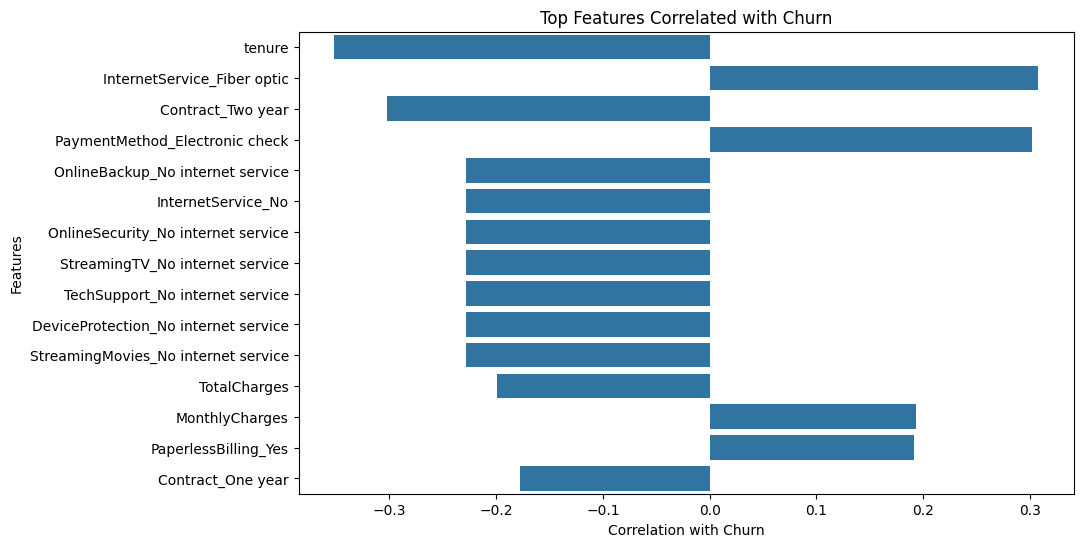

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top Features Correlated with Churn')
plt.xlabel('Correlation with Churn')
plt.ylabel('Features')
plt.show()

#### Top Features Correlated with Churn

The correlation analysis shows that `tenure`, contract type, internet service, payment method, technical support, online security, monthly charges, and total charges are among the most important variables related to customer churn.

Some variables have positive correlation with churn, meaning they are associated with a higher probability of churn. Other variables have negative correlation, meaning they are associated with a lower probability of churn.

For example, `tenure` has a negative correlation with churn, which means customers who stay longer with the company are less likely to churn.

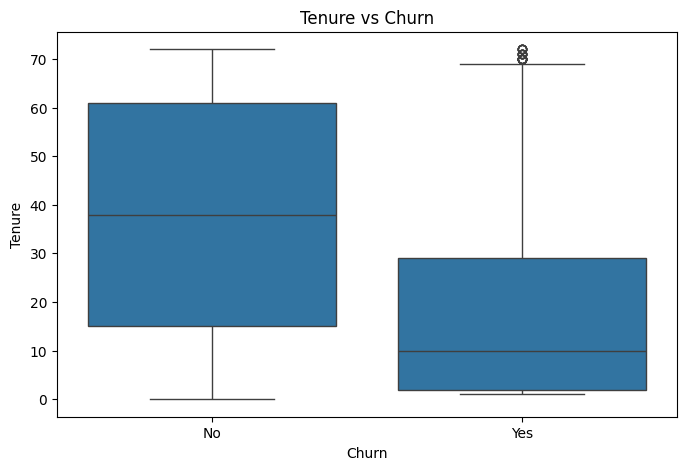

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure vs Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

Customers who churned usually have lower tenure compared to customers who did not churn. This means that newer customers are more likely to leave the company, while long-term customers are more likely to stay.

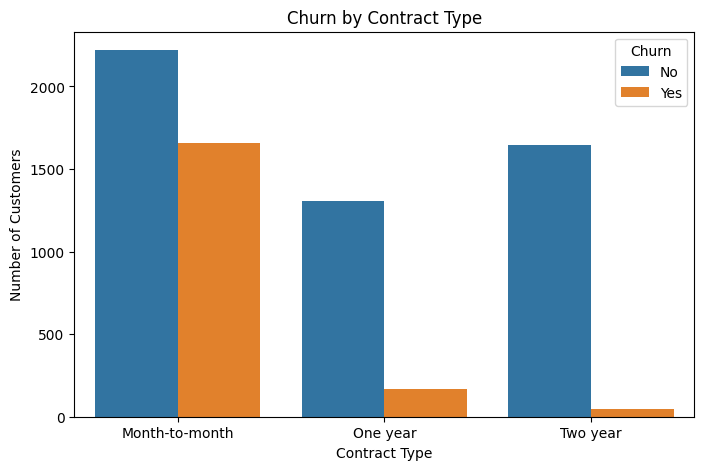

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Customers with month-to-month contracts appear to have a higher churn rate compared to customers with one-year or two-year contracts. Longer contracts are associated with lower churn.

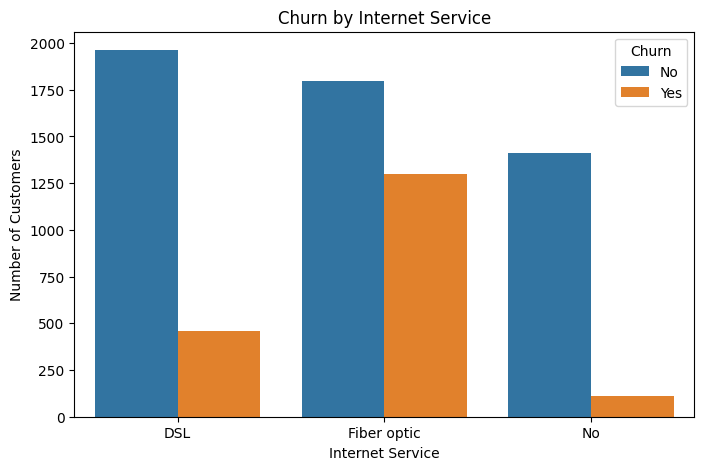

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

Internet service type is related to churn. Customers with certain internet service types show different churn behavior, which suggests that the type of service may influence customer retention.

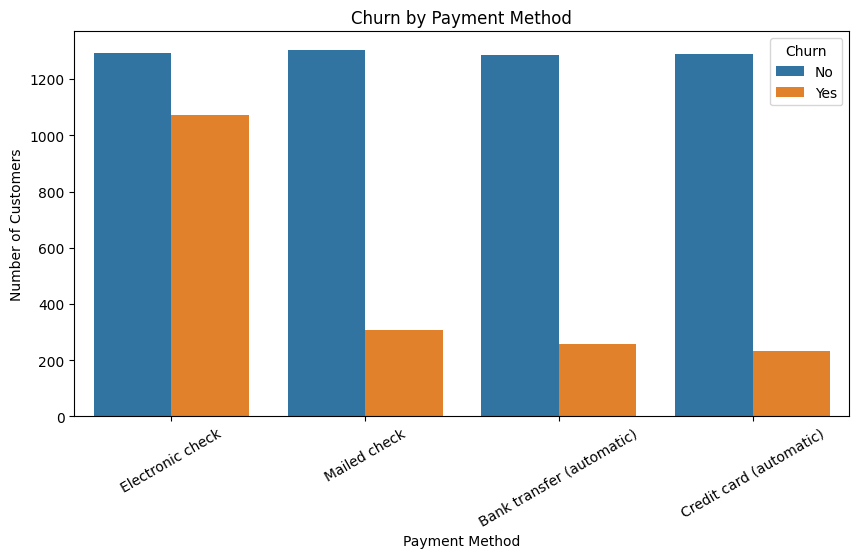

In [20]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.show()

Payment method appears to be associated with churn. Some payment methods have a higher number of churned customers, which may indicate differences in customer behavior based on payment preference.

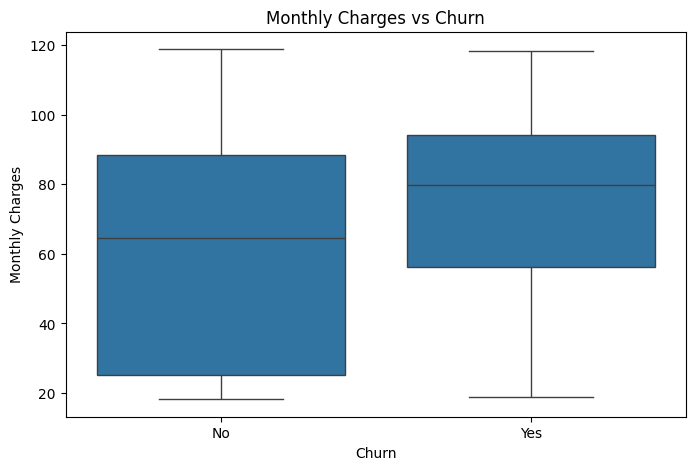

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

Customers who churned tend to have higher monthly charges. This suggests that customers paying higher monthly fees may be more likely to leave the company.

In [22]:
df_clean = df.copy()

df_clean.to_csv('before_cleaning.csv', index=False)